# 01 - The dataset before any windowing

This notebook answers one question: **what is actually in this data?** It runs
before any window, any label and any model, and everything it reports is a
property of the raw dataset rather than of a modelling choice.

The source is the `prom_slurm_joined` table from the SURF Lisa academic HPC
cluster (Chu et al., ICPADS 2024, arXiv:2409.08949): Prometheus node telemetry
joined to Slurm job metadata, one row per (node, timestamp) per job.

**Order of the steps**

1. Census of the whole table, with no filter at all -- how many jobs and
   snapshots exist, and how many are GPU jobs.
2. The population funnel -- what each filtering decision costs us.
3. Build the job table (one row per job) that the rest of the analysis uses.
4. Jobs per label, and why the label mix looks different in snapshots.
5. Job duration per label -- the number that turns out to matter most.
6. Telemetry cadence and gaps -- what justifies a 40-snapshot window.
7. **Node sharing** -- how many jobs sit on the same node at the same moment.
8. Temporal drift -- why the train/test split has to be by time.
9. Hardware and queue context.
10. Are TIMEOUT jobs really a walltime problem?
11. Column health -- which metric columns are usable.

Everything is written to `data/` (git-ignored, rebuilt by running the notebook)
and `figures/` (committed).

In [2]:
# --- Setup: paths, constants, plotting -------------------------------------
# This block is repeated verbatim at the top of all three notebooks so that each
# one can be read and run on its own. The notebooks share *data* (the parquet
# files written into data/), never code.
from pathlib import Path
import json, time, gc
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.compute as pc
import matplotlib as mpl
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / "dataset").exists() else Path.cwd().parent
RAW    = ROOT / "dataset" / "prom_slurm_joined" / "prom_slurm_joined.parquet"
HWINFO = ROOT / "dataset" / "node_hardware_info.parquet"
DATA, FIGS = Path("data"), Path("figures")
DATA.mkdir(exist_ok=True); FIGS.mkdir(exist_ok=True)

# --- Pipeline constants ----------------------------------------------------
WINDOW     = 40     # snapshots per window -> 20 minutes at a 30 s cadence
HORIZON_H  = 2.0    # a snapshot is positive within 2 h of a failing job's end
GAP_TOL_S  = 60.0   # reject any window that contains a larger gap than this
STRIDE     = 10     # keep every 10th window start inside a series
TRAIN_FRAC = 0.8    # temporal split: the first 80 % of jobs by end_date
SNAP_S     = 30.0   # telemetry cadence -- verified in step 6 below

# "OOM" always denotes the OUT_OF_MEMORY *job state*, never a machine that ran
# out of RAM.
FAILURE_STATES = ("FAILED", "TIMEOUT", "OUT_OF_MEMORY", "NODE_FAIL")
STATES = ("COMPLETED",) + FAILURE_STATES
COLOR = {"COMPLETED": "#9aa0a6", "TIMEOUT": "#4c78a8", "FAILED": "#f58518",
         "OUT_OF_MEMORY": "#b279a2", "NODE_FAIL": "#54a24b"}

mpl.rcParams.update({"figure.dpi": 110, "savefig.dpi": 140, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25,
                     "figure.facecolor": "white", "axes.axisbelow": True})

def save(fig, name):
    """Write a figure into figures/ and return it so the cell still displays it."""
    fig.savefig(FIGS / name, bbox_inches="tight")
    return fig

print("dataset:", RAW, "|", "found" if RAW.exists() else "MISSING")

dataset: d:\_fcall\UNIFEI\tcc\hpc_workload\dataset\prom_slurm_joined\prom_slurm_joined.parquet | found


## 1. Census of the table

The table is ~10 GB on disk in 200 parts, so we never load it. Instead each part
is grouped in Arrow down to one row per `(slurm_id, state, gpu_node)` and only
those small summaries are concatenated. This reads the whole table in about 15
seconds and uses a few hundred MB.

In [3]:
census_path = DATA / "raw_census.parquet"

if census_path.exists():
    census = pd.read_parquet(census_path)
    print("loaded cached census")
else:
    t0 = time.time()
    parts = sorted(RAW.glob("part-*.parquet"))
    chunks = []
    for i, p in enumerate(parts):
        tab = pq.read_table(p, columns=["slurm_id", "state", "gpu_node", "timestamp"])
        chunks.append(tab.group_by(["slurm_id", "state", "gpu_node"]).aggregate(
            [("timestamp", "min"), ("timestamp", "max"), ([], "count_all")]))
    census = pa.concat_tables(chunks).to_pandas()
    # A job can be split across parts, so collapse the per-part summaries.
    census = (census.groupby(["slurm_id", "state", "gpu_node"], as_index=False)
                    .agg(first_ts=("timestamp_min", "min"),
                         last_ts=("timestamp_max", "max"),
                         n_snap=("count_all", "sum")))
    census.to_parquet(census_path, index=False)
    print(f"scanned {len(parts)} parts in {time.time() - t0:.0f}s")

# Sanity: a job must have exactly one state and one gpu_node flag.
assert census.slurm_id.is_unique, "a slurm_id appeared with two different states"

n_snap_all = int(census.n_snap.sum())
n_jobs_all = len(census)
gpu = census[census.gpu_node == 1]
gpu_nc = gpu[gpu.state != "CANCELLED"]

print(f"TOTAL snapshots        {n_snap_all:>12,}")
print(f"TOTAL jobs             {n_jobs_all:>12,}")
print(f"GPU jobs               {len(gpu):>12,}   ({len(gpu)/n_jobs_all:.1%} of all jobs)")
print(f"GPU jobs, non-CANCELLED{len(gpu_nc):>12,}")
print(f"GPU snapshots          {int(gpu.n_snap.sum()):>12,}")
print(f"GPU snapshots, non-CAN.{int(gpu_nc.n_snap.sum()):>12,}")

loaded cached census
TOTAL snapshots          93,950,875
TOTAL jobs                  293,891
GPU jobs                     27,287   (9.3% of all jobs)
GPU jobs, non-CANCELLED      23,618
GPU snapshots            13,459,188
GPU snapshots, non-CAN.  11,144,842


In [3]:
print("jobs and snapshots by (gpu_node, state):\n")
tab = census.groupby(["gpu_node", "state"]).agg(jobs=("slurm_id", "size"),
                                                snapshots=("n_snap", "sum"))
print(tab.to_string())

# Which parts actually hold GPU rows? (uses row-group statistics only, no data)
parts = sorted(RAW.glob("part-*.parquet"))
gpu_parts = []
for i, p in enumerate(parts):
    st = pq.ParquetFile(p).metadata.row_group(0).column(
        pq.ParquetFile(p).schema_arrow.names.index("gpu_node")).statistics
    if st.max == 1:
        gpu_parts.append(i)
print(f"\nparts containing gpu_node=1 rows: {len(gpu_parts)} of {len(parts)} "
      f"(indices {min(gpu_parts)}-{max(gpu_parts)})")

jobs and snapshots by (gpu_node, state):

                          jobs  snapshots
gpu_node state                           
0        CANCELLED        9592    6196099
         COMPLETED      202874   43195044
         FAILED          37588    4504303
         NODE_FAIL        1426    2260157
         OUT_OF_MEMORY    4499     672292
         TIMEOUT         10625   23663792
1        CANCELLED        3669    2314346
         COMPLETED       17306    6769458
         FAILED           4664     631137
         NODE_FAIL         107      27951
         OUT_OF_MEMORY     130      73016
         TIMEOUT          1411    3643280



parts containing gpu_node=1 rows: 29 of 200 (indices 171-199)


## 2. The population funnel

When modelling the data for this project, we make a few exclusions:

- **GPU nodes only.** The project is about GPU-node health, and the GPU metric
  columns are null on the rest of the cluster.
- **Drop CANCELLED.** A cancelled job says nothing about node health. It is caused because a user
  pressed stop.
- **At least 40 snapshots.** A job shorter than one window cannot produce a
  single feature row, so it is invisible to this technique no matter how good
  the model is.

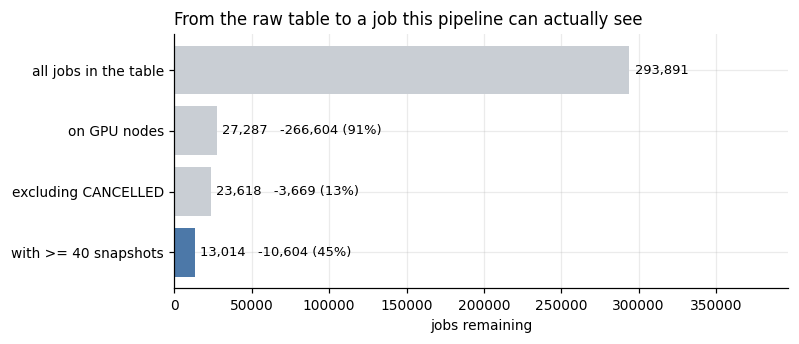

13,014 of 293,891 jobs survive = 4.4% of the table


In [4]:
steps = [
    ("all jobs in the table", n_jobs_all),
    ("on GPU nodes", len(gpu)),
    ("excluding CANCELLED", len(gpu_nc)),
    (f"with >= {WINDOW} snapshots", int((gpu_nc.n_snap >= WINDOW).sum())),
]
fig, ax = plt.subplots(figsize=(7.2, 3.0))
labels = [s[0] for s in steps]; vals = [s[1] for s in steps]
bars = ax.barh(range(len(steps)), vals, color=["#c9ced4", "#c9ced4", "#c9ced4", "#4c78a8"])
ax.set_yticks(range(len(steps)), labels); ax.invert_yaxis()
ax.set_xlabel("jobs remaining")
for i, (b, v) in enumerate(zip(bars, vals)):
    lost = "" if i == 0 else f"   -{vals[i-1] - v:,} ({(vals[i-1]-v)/vals[i-1]:.0%})"
    ax.text(v + n_jobs_all * 0.012, b.get_y() + b.get_height()/2,
            f"{v:,}{lost}", va="center", fontsize=8.5)
ax.set_xlim(0, n_jobs_all * 1.35)
ax.set_title("From the raw table to a job this pipeline can actually see", loc="left")
save(fig, "01_funnel.png"); plt.show()

print(f"{vals[-1]:,} of {n_jobs_all:,} jobs survive = {vals[-1]/n_jobs_all:.1%} of the table")

## 3. The job table

From here on the population is fixed: **GPU nodes, CANCELLED excluded**. Here, we are loading
the key columns for every snapshot in that population and reduce it to one row per job.

Two duration measures are kept:

- `slurm_h` = `end_date - start_date`, the job's true runtime according to Slurm;
- `tele_h`  = `last_ts - first_ts`, the span actually covered by telemetry.

They are used to check consistency in the table.

In [4]:
KEYS = ["slurm_id", "node", "timestamp", "state", "start_date", "end_date",
        "nodetypes", "numnodes", "numcores"]

t0 = time.time()
tabs = []
for p in sorted(RAW.glob("part-*.parquet")):
    tab = pq.read_table(p, columns=KEYS + ["gpu_node"])
    tab = tab.filter((pc.field("gpu_node") == 1) & (pc.field("state") != "CANCELLED"))
    if tab.num_rows:
        tabs.append(tab.drop_columns(["gpu_node"]))
snap = pa.concat_tables(tabs).to_pandas()
del tabs; gc.collect()
for c in ("node", "state", "nodetypes"):
    snap[c] = snap[c].astype("category")
snap = snap.sort_values(["slurm_id", "node", "timestamp"], kind="stable", ignore_index=True)
print(f"{len(snap):,} snapshots, {snap.memory_usage(deep=True).sum()/1e6:.0f} MB, "
      f"{time.time()-t0:.0f}s")

11,144,842 snapshots, 435 MB, 29s


In [6]:
g = snap.groupby("slurm_id", observed=True)
jobs = pd.DataFrame({
    "state":      g.state.first(),
    "nodetypes":  g.nodetypes.first(),
    "node":       g.node.first(),          # primary node (a job may span several)
    "numnodes":   g.numnodes.first(),      # nodes Slurm allocated
    "numcores":   g.numcores.first(),
    "start_date": g.start_date.first(),
    "end_date":   g.end_date.first(),
    "first_ts":   g.timestamp.min(),
    "last_ts":    g.timestamp.max(),
    "n_snap":     g.size(),
    "n_nodes_seen": g.node.nunique(),      # nodes that actually reported telemetry
}).reset_index()

jobs["slurm_h"]    = (jobs.end_date - jobs.start_date).dt.total_seconds() / 3600
jobs["tele_h"]     = (jobs.last_ts - jobs.first_ts).dt.total_seconds() / 3600
jobs["is_failure"] = jobs.state.isin(FAILURE_STATES)
jobs["node_hours"] = jobs.slurm_h * jobs.numnodes

# Temporal split: the earliest 80 % of jobs by end_date are train. Ties are
# broken on slurm_id so the split is deterministic.
order = jobs.sort_values(["end_date", "slurm_id"], kind="stable").index
n_train = int(len(jobs) * TRAIN_FRAC)
jobs["split"] = "test"
jobs.loc[order[:n_train], "split"] = "train"
SPLIT_TIME = jobs.loc[order[n_train], "end_date"]

jobs.to_parquet(DATA / "jobs.parquet", index=False)
print(f"{len(jobs):,} jobs -> data/jobs.parquet")
print(f"split time (first {TRAIN_FRAC:.0%} of jobs by end_date): {SPLIT_TIME}")
print(f"train {int((jobs.split=='train').sum()):,} | test {int((jobs.split=='test').sum()):,}")
print(f"\ntelemetry period: {snap.timestamp.min()} -> {snap.timestamp.max()} "
      f"({(snap.timestamp.max()-snap.timestamp.min()).days} days)")
print(f"nodes: {snap.node.nunique()}")

23,618 jobs -> data/jobs.parquet
split time (first 80% of jobs by end_date): 2022-10-19 11:50:16
train 18,894 | test 4,724

telemetry period: 2022-08-25 10:27:00 -> 2022-11-01 13:58:00 (68 days)


nodes: 51


In [7]:
T0, T1 = snap.timestamp.min(), snap.timestamp.max()
gap_end = (jobs.end_date - jobs.last_ts).dt.total_seconds()
print(f"jobs starting before telemetry begins : {int((jobs.start_date < T0).sum()):>5}")
print(f"jobs ending after telemetry stops     : {int((jobs.end_date > T1).sum()):>5}")
print(f"median (slurm_h - tele_h)             : {((jobs.slurm_h-jobs.tele_h)*60).median():.2f} min"
      f"   <- one cadence step, as expected")
print(f"jobs whose telemetry stops >5 min early: {int((gap_end > 300).sum()):>5} "
      f"({(gap_end > 300).mean():.1%})")
print(f"\nSlurm says >1 node for {int((jobs.numnodes > 1).sum())} jobs; "
      f"telemetry actually covers >1 node for {int((jobs.n_nodes_seen > 1).sum())}.")

jobs starting before telemetry begins :    36
jobs ending after telemetry stops     :     1
median (slurm_h - tele_h)             : 0.47 min   <- one cadence step, as expected
jobs whose telemetry stops >5 min early:   211 (0.9%)

Slurm says >1 node for 152 jobs; telemetry actually covers >1 node for 123.


## 4. Jobs per label / Snapshots per label

The five Slurm end states are the labels. Four of them count as failures for
this project.

The bar chart shows the same population twice: once as a **share of jobs**, once
as a **share of snapshots**. The two are very different, and the difference is
the first hint of the coverage problem: failures that take a long time (TIMEOUT)
dominate the telemetry, while failures that are over in a minute (FAILED)
barely appear in it even though they are the most numerous failure by job count.

In [8]:
by_state = pd.DataFrame({
    "jobs":      jobs.groupby("state", observed=True).size(),
    "snapshots": jobs.groupby("state", observed=True).n_snap.sum(),
}).reindex(STATES)
by_state["job_share"]  = by_state.jobs / by_state.jobs.sum()
by_state["snap_share"] = by_state.snapshots / by_state.snapshots.sum()
by_state["node_hours"] = jobs.groupby("state", observed=True).node_hours.sum().reindex(STATES)
print(by_state.to_string(formatters={"job_share": "{:.2%}".format,
                                     "snap_share": "{:.2%}".format,
                                     "node_hours": "{:,.0f}".format}))
print(f"\nfailure rate, by job:      {jobs.is_failure.mean():.2%}")
print(f"failure rate, by snapshot: "
      f"{by_state.loc[list(FAILURE_STATES),'snapshots'].sum()/by_state.snapshots.sum():.2%}")

                jobs  snapshots job_share snap_share node_hours
state                                                          
COMPLETED      17306    6769458    73.27%     60.74%     58,012
FAILED          4664     631137    19.75%      5.66%      5,343
TIMEOUT         1411    3643280     5.97%     32.69%     31,044
OUT_OF_MEMORY    130      73016     0.55%      0.66%        625
NODE_FAIL        107      27951     0.45%      0.25%        237

failure rate, by job:      26.73%
failure rate, by snapshot: 39.26%


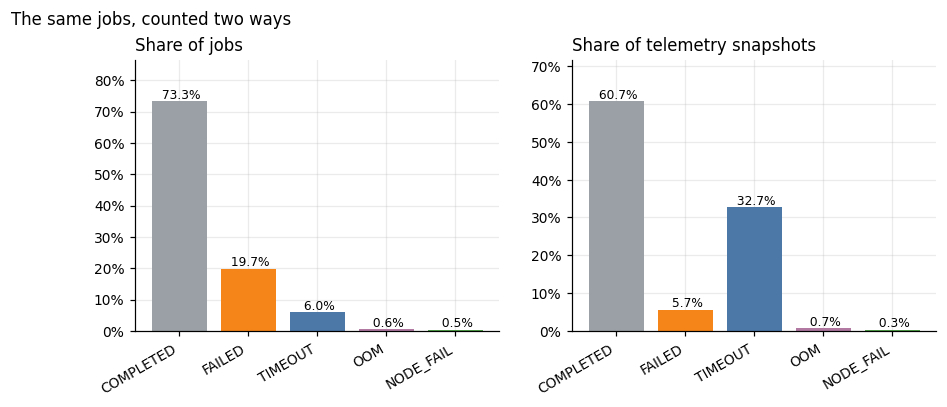

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.2))
for ax, col, title in zip(axes, ["job_share", "snap_share"],
                          ["Share of jobs", "Share of telemetry snapshots"]):
    v = by_state[col]
    ax.bar(range(len(v)), v.values, color=[COLOR[s] for s in v.index])
    ax.set_xticks(range(len(v)), [s.replace("OUT_OF_MEMORY", "OOM") for s in v.index],
                  rotation=30, ha="right")
    ax.set_title(title, loc="left")
    ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
    for i, val in enumerate(v.values):
        ax.text(i, val, f" {val:.1%}", ha="center", va="bottom", fontsize=8)
    ax.set_ylim(0, max(v.values) * 1.18)
fig.suptitle("The same jobs, counted two ways", x=0.005, ha="left", y=1.02)
save(fig, "02_labels.png"); plt.show()

## 5. How long do jobs run?

This is the most consequential plot in the notebook. The technique needs at
least `WINDOW` consecutive snapshots (20 minutes) before it can emit anything at
all, and ideally it needs them well before the job ends.

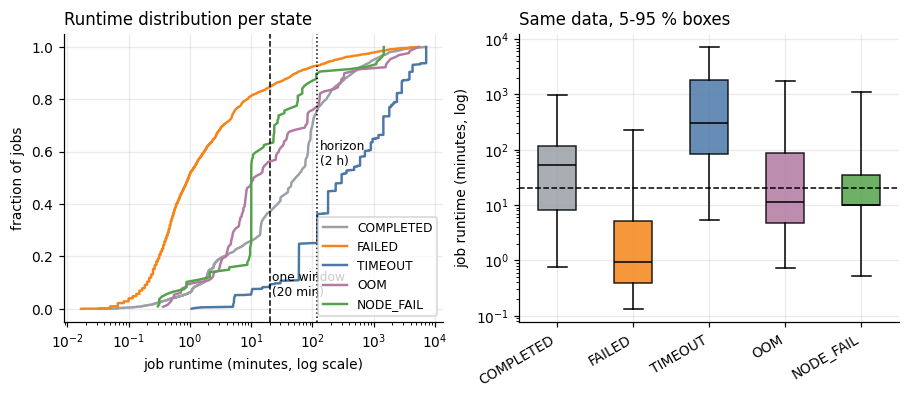

                jobs median_min p90_min shorter_than_window
state                                                      
COMPLETED      17306       52.7   449.5               36.9%
FAILED          4664        1.0    53.5               84.7%
TIMEOUT         1411      300.2  3840.5                8.5%
OUT_OF_MEMORY    130       11.5   344.6               56.2%
NODE_FAIL        107       10.1   123.0               65.4%


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9.8, 3.4))

ax = axes[0]
for s in STATES:
    d = np.sort(jobs.loc[jobs.state == s, "slurm_h"].to_numpy() * 60)
    d = d[d > 0]
    ax.plot(d, np.arange(1, len(d) + 1) / len(d), color=COLOR[s], lw=1.6,
            label=s.replace("OUT_OF_MEMORY", "OOM"))
ax.axvline(WINDOW * SNAP_S / 60, color="k", ls="--", lw=1)
ax.text(WINDOW * SNAP_S / 60 * 1.1, 0.05, f"one window\n({WINDOW*SNAP_S/60:.0f} min)", fontsize=8)
ax.axvline(HORIZON_H * 60, color="k", ls=":", lw=1)
ax.text(HORIZON_H * 60 * 1.1, 0.55, f"horizon\n({HORIZON_H:.0f} h)", fontsize=8)
ax.set_xscale("log"); ax.set_xlabel("job runtime (minutes, log scale)")
ax.set_ylabel("fraction of jobs"); ax.legend(fontsize=8, loc="lower right")
ax.set_title("Runtime distribution per state", loc="left")

ax = axes[1]
data = [jobs.loc[jobs.state == s, "slurm_h"].to_numpy() * 60 for s in STATES]
bp = ax.boxplot(data, vert=True, whis=(5, 95), showfliers=False, patch_artist=True,
                medianprops=dict(color="black"))
for patch, s in zip(bp["boxes"], STATES):
    patch.set_facecolor(COLOR[s]); patch.set_alpha(0.85)
ax.set_yscale("log")
ax.set_xticks(range(1, len(STATES) + 1),
              [s.replace("OUT_OF_MEMORY", "OOM") for s in STATES], rotation=30, ha="right")
ax.axhline(WINDOW * SNAP_S / 60, color="k", ls="--", lw=1)
ax.set_ylabel("job runtime (minutes, log)")
ax.set_title("Same data, 5-95 % boxes", loc="left")
save(fig, "03_duration.png"); plt.show()

dur = jobs.groupby("state", observed=True).agg(
    jobs=("slurm_id", "size"),
    median_min=("slurm_h", lambda s: s.median() * 60),
    p90_min=("slurm_h", lambda s: s.quantile(.9) * 60),
    shorter_than_window=("n_snap", lambda s: (s < WINDOW).mean()),
).reindex(STATES)
print(dur.to_string(formatters={"median_min": "{:.1f}".format, "p90_min": "{:.1f}".format,
                                "shorter_than_window": "{:.1%}".format}))

Read the `shorter_than_window` column carefully, because it is a ceiling on
recall that no model can lift:

- **FAILED** jobs -- the most common failure by count -- have a median runtime of
  about one minute. The large majority never produce a single complete window.
- **NODE_FAIL** is nearly as bad.
- **TIMEOUT** is the opposite: those jobs run for hours, so almost all of them
  are observable.

Whatever a model scores later, it can only score it on the jobs that survive
this table.

In [11]:
short = jobs[jobs.is_failure].groupby("state", observed=True).apply(
    lambda d: pd.Series({
        "failing jobs": len(d),
        "shorter than one window": (d.n_snap < WINDOW).mean(),
        "shorter than the horizon": (d.slurm_h < HORIZON_H).mean(),
    }), include_groups=False)
print(short.to_string(formatters={"shorter than one window": "{:.1%}".format,
                                  "shorter than the horizon": "{:.1%}".format}))
f = jobs[jobs.is_failure]
print(f"\nall failing jobs shorter than the {HORIZON_H:.0f} h horizon: "
      f"{(f.slurm_h < HORIZON_H).mean():.1%} (Slurm runtime) / "
      f"{(f.tele_h < HORIZON_H).mean():.1%} (telemetry span)")

               failing jobs shorter than one window shorter than the horizon
state                                                                       
FAILED               4664.0                   84.7%                    92.9%
NODE_FAIL             107.0                   65.4%                    89.7%
OUT_OF_MEMORY         130.0                   56.2%                    76.9%
TIMEOUT              1411.0                    8.5%                    25.1%

all failing jobs shorter than the 2 h horizon: 77.3% (Slurm runtime) / 78.7% (telemetry span)


## 6. Cadence and gaps

The window length is expressed in *snapshots*, so it only means "20 minutes" if
the cadence is really 30 seconds. We measure it inside each `(job, node)` series
rather than globally, because that is the sequence a window is actually cut
from.

intervals measured: 11,121,070


median 30.0s | mean 30.3s
exactly 30s: 99.9942%
longer than GAP_TOL_S=60s: 610 (0.00549%)
largest gap: 2.02 h


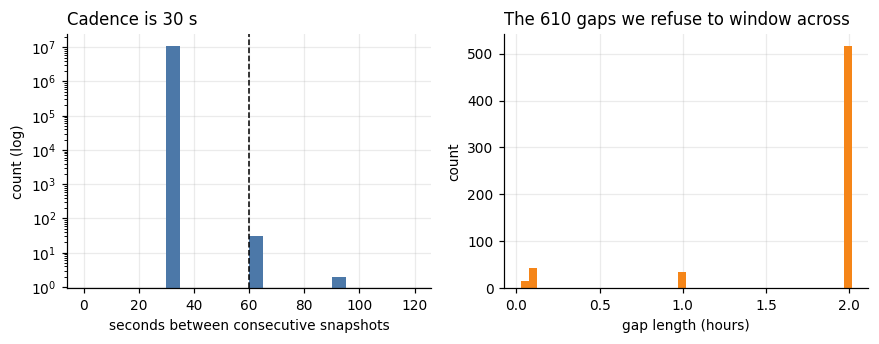


most common large gap: {2.01: 483, 0.08: 37, 1.01: 34}
A single value dominating the large gaps means one cluster-wide monitoring
outage rather than per-node flakiness.


In [12]:
sid = snap.slurm_id.astype(np.int64).to_numpy() * 1000 + snap.node.cat.codes.to_numpy()
ts_ns = snap.timestamp.astype("int64").to_numpy()
same_series = sid[1:] == sid[:-1]
dt = np.diff(ts_ns)[same_series] / 1e9

print(f"intervals measured: {len(dt):,}")
print(f"median {np.median(dt):.1f}s | mean {dt.mean():.1f}s")
print(f"exactly {SNAP_S:.0f}s: {(dt == SNAP_S).mean():.4%}")
print(f"longer than GAP_TOL_S={GAP_TOL_S:.0f}s: {int((dt > GAP_TOL_S).sum()):,} "
      f"({(dt > GAP_TOL_S).mean():.5%})")
print(f"largest gap: {dt.max()/3600:.2f} h")

fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.0))
axes[0].hist(dt[dt <= 120], bins=np.arange(0, 125, 5), color="#4c78a8")
axes[0].set_yscale("log"); axes[0].set_xlabel("seconds between consecutive snapshots")
axes[0].set_ylabel("count (log)"); axes[0].axvline(GAP_TOL_S, color="k", ls="--", lw=1)
axes[0].set_title(f"Cadence is {SNAP_S:.0f} s", loc="left")

big = dt[dt > GAP_TOL_S] / 3600
axes[1].hist(big, bins=40, color="#f58518")
axes[1].set_xlabel("gap length (hours)"); axes[1].set_ylabel("count")
axes[1].set_title(f"The {len(big):,} gaps we refuse to window across", loc="left")
save(fig, "04_cadence.png"); plt.show()

print(f"\nmost common large gap: {pd.Series(big.round(2)).value_counts().head(3).to_dict()}")
print("A single value dominating the large gaps means one cluster-wide monitoring")
print("outage rather than per-node flakiness.")

The cadence is 30 seconds for 99.8 % of intervals, so `WINDOW = 40` really is 20
minutes of wall-clock history. Gaps are rare (about 0.005 % of intervals) but
they are not random: one gap length dominates, which is the signature of a
single cluster-wide monitoring outage.

A window that straddles a gap would compute a mean over telemetry hours apart,
so we reject those windows in notebook 02. Because gaps are this rare, that
costs almost nothing.

## 7. Node sharing: several jobs, one telemetry row

This step is not in the original plan for the analysis, but it turned out to be
an important property of the dataset.

Most of the queues on this cluster are **shared** (`gpu_shared`,
`gpu_titanrtx_shared`, ...): several jobs run on the same physical node at the
same time. The telemetry, however, is collected **per node**, and the join
attaches the same node row to every job running there. So two different jobs can
receive *byte-identical* feature values while ending in different states.

Let us measure how often that happens.

In [13]:
dupe = snap.duplicated(subset=["node", "timestamp"], keep=False)
grp = snap.groupby(["node", "timestamp"], observed=True).slurm_id.nunique()

print(f"snapshots sharing their (node, timestamp) with another job: "
      f"{dupe.mean():.1%}  ({int(dupe.sum()):,})")
print(f"concurrent jobs per node-snapshot: mean {grp.mean():.2f}, max {int(grp.max())}")
print("\ndistribution of concurrent jobs per node-snapshot:")
print(grp.value_counts().sort_index().to_string())

snap["co_tenanted"] = dupe.to_numpy()
per_queue = snap.groupby("nodetypes", observed=True).co_tenanted.agg(["mean", "size"])
print("\nco-tenancy by queue:")
print(per_queue.sort_values("size", ascending=False).to_string(
    formatters={"mean": "{:.1%}".format, "size": "{:,}".format}))

snapshots sharing their (node, timestamp) with another job: 78.4%  (8,740,208)
concurrent jobs per node-snapshot: mean 2.07, max 5

distribution of concurrent jobs per node-snapshot:
slurm_id
1    2404634
2    1171394
3     868169
4     948122
5         85



co-tenancy by queue:
                            mean      size
nodetypes                                 
gpu_titanrtx_shared        87.0% 6,018,015
gpu_shared                 87.1% 3,484,502
gpu_titanrtx                0.0%   741,595
gpu                         0.0%   305,424
gpu_shared_course          78.4%   263,576
fat_soil_shared            81.9%   251,765
gpu_titanrtx_shared_course 83.3%    58,442
gpu_shared_jupyter         46.3%    21,523


Two queues (`gpu` and `gpu_titanrtx`) are **exclusive** -- one job per node -- and
show 0 % co-tenancy. Everything else is shared.

Now the part that matters. Label a snapshot positive when its job ends in a
failure state within `HORIZON_H` hours. If a node-snapshot serves several jobs
and they do not agree on that label, then the feature vector is identical but
the target is not, and *no* classifier using only node-level telemetry can
separate them. That is a hard floor on achievable recall, set by the data rather
than by the algorithm.

In [14]:
ttf = (snap.end_date - snap.timestamp).dt.total_seconds().to_numpy()
pos = (snap.state.isin(FAILURE_STATES).to_numpy()
       & (ttf >= 0) & (ttf <= HORIZON_H * 3600)).astype(np.int32)
snap["pos"] = pos
n_pos = int(pos.sum())

g2 = snap.groupby(["node", "timestamp"], observed=True).pos
n_in_group = g2.size().to_numpy()
n_pos_in_group = g2.sum().to_numpy()
co = n_in_group > 1
contradictory = co & (n_pos_in_group > 0) & (n_pos_in_group < n_in_group)

# An oracle forced to give one answer per identical row loses the minority side.
floor = int(np.minimum(n_pos_in_group, n_in_group - n_pos_in_group).sum())

print(f"snapshot positive rate: {pos.mean():.4f}  ({n_pos:,} positives)")
print(f"node-snapshots: {len(n_in_group):,}, of which co-tenanted {co.mean():.1%}")
print(f"co-tenanted node-snapshots with CONTRADICTORY labels: "
      f"{contradictory.sum()/co.sum():.2%} of co-tenanted")
print(f"\npositive snapshots that share their row with a non-failing job: "
      f"{int(n_pos_in_group[contradictory].sum()):,} / {n_pos:,} "
      f"({n_pos_in_group[contradictory].sum()/n_pos:.1%})")
print(f"snapshots an ORACLE must get wrong using node-level features alone: "
      f"{floor:,} ({floor/n_pos:.1%} of all positives)")
print(f"\n=> ceiling on recall from node-level telemetry: about {1-floor/n_pos:.0%}")

snapshot positive rate: 0.0382  (425,974 positives)
node-snapshots: 5,392,404, of which co-tenanted 55.4%
co-tenanted node-snapshots with CONTRADICTORY labels: 7.03% of co-tenanted

positive snapshots that share their row with a non-failing job: 241,303 / 425,974 (56.6%)
snapshots an ORACLE must get wrong using node-level features alone: 220,269 (51.7% of all positives)

=> ceiling on recall from node-level telemetry: about 48%


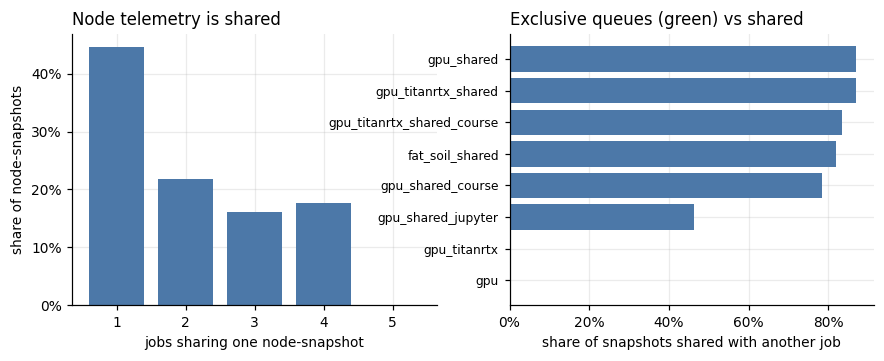

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.2))

ax = axes[0]
vc = grp.value_counts().sort_index()
ax.bar(vc.index, vc.values / vc.sum(), color="#4c78a8")
ax.set_xlabel("jobs sharing one node-snapshot"); ax.set_ylabel("share of node-snapshots")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.set_title("Node telemetry is shared", loc="left")

ax = axes[1]
q = snap.groupby("nodetypes", observed=True).co_tenanted.mean().sort_values()
colors = ["#4c78a8" if v > 0 else "#54a24b" for v in q.values]
ax.barh(range(len(q)), q.values, color=colors)
ax.set_yticks(range(len(q)), q.index, fontsize=8)
ax.set_xlabel("share of snapshots shared with another job")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.set_title("Exclusive queues (green) vs shared", loc="left")
save(fig, "05_co_tenancy.png"); plt.show()

About 56 % of positive snapshots sit on a telemetry row that also belongs to a job which is *not* about
to fail. An oracle with perfect knowledge of the features, forced to answer once
per distinct row, gets roughly half of the positives wrong.

It explains something earlier sessions observed but could not account for: a
model on this feature set plateaus at roughly 3x the random baseline no matter
what is done to it. Part of that plateau is not a modelling failure at all -- it
is the label being underdetermined by the features.

It also points at the fix. On the two exclusive queues the label *is*
determined by the node, and that subset is where this technique is well posed.

The weekly failure rate moves by more than a factor of two across ten weeks. A
model validated on a random shuffle of these jobs would be tested on weeks it
had already seen, which is precisely the leak that made shuffled cross-validation
in earlier sessions report scores several times better than the truth.

## 8. Hardware and queues

`node_hardware_info.parquet` gives the GPU model of every node, and `nodetypes`
gives the queue the job was submitted to.

In [17]:
hw = pd.read_parquet(HWINFO)[["node", "gpu_model", "gpu_count",
                              "gpu_memory_bytes_per_card", "cpu_model"]]
jh = jobs.merge(hw, on="node", how="left")
assert jh.gpu_model.notna().all(), "a node is missing from node_hardware_info"

print("by GPU model:")
print(jh.groupby("gpu_model", observed=True).agg(
    nodes=("node", "nunique"), jobs=("slurm_id", "size"),
    failure_rate=("is_failure", "mean"),
    median_runtime_min=("slurm_h", lambda s: s.median() * 60)).to_string(
        formatters={"failure_rate": "{:.1%}".format, "median_runtime_min": "{:.1f}".format}))

print("\nby queue:")
qs = jh.groupby("nodetypes", observed=True).agg(
    jobs=("slurm_id", "size"), failure_rate=("is_failure", "mean"),
    median_runtime_min=("slurm_h", lambda s: s.median() * 60))
for s in FAILURE_STATES:
    qs[s] = jh.assign(x=jh.state == s).groupby("nodetypes", observed=True).x.mean()
print(qs.sort_values("jobs", ascending=False).to_string(
    formatters={c: "{:.1%}".format for c in ["failure_rate"] + list(FAILURE_STATES)}
    | {"median_runtime_min": "{:.1f}".format}))

by GPU model:
                            nodes   jobs failure_rate median_runtime_min
gpu_model                                                               
NVIDIA_GeForce_GTX_1080_Ti     20  13311        25.1%               23.5
NVIDIA_TITAN_RTX               31  10307        28.8%               40.1

by queue:
                             jobs failure_rate median_runtime_min FAILED TIMEOUT OUT_OF_MEMORY NODE_FAIL
nodetypes                                                                                               
gpu_shared                  10890        17.2%               45.0  12.5%    4.0%          0.2%      0.4%
gpu_titanrtx_shared          8280        29.5%               52.4  20.7%    7.9%          0.5%      0.4%
gpu_shared_course            1904        64.8%                2.7  59.5%    3.0%          1.8%      0.5%
gpu_titanrtx                 1440        21.0%               40.1  15.6%    4.4%          0.3%      0.7%
gpu                           404        35.9%       

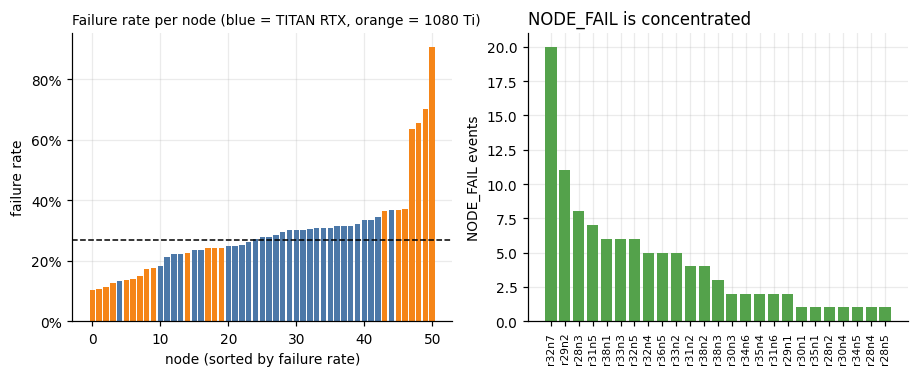

failure rate per node: min 10.2%, median 27.8%, max 90.7%
NODE_FAIL: 107 events on 25 of 51 nodes; worst node r32n7 has 20


In [18]:
per_node = jh.groupby("node", observed=True).agg(
    jobs=("slurm_id", "size"), failure_rate=("is_failure", "mean"),
    gpu_model=("gpu_model", "first")).sort_values("failure_rate")
nf = jh[jh.state == "NODE_FAIL"].node.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(9.8, 3.4))
ax = axes[0]
ax.bar(range(len(per_node)), per_node.failure_rate,
       color=["#4c78a8" if m == "NVIDIA_TITAN_RTX" else "#f58518"
              for m in per_node.gpu_model])
ax.axhline(jobs.is_failure.mean(), color="k", ls="--", lw=1)
ax.set_xlabel("node (sorted by failure rate)"); ax.set_ylabel("failure rate")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.set_title("Failure rate per node (blue = TITAN RTX, orange = 1080 Ti)", loc="left",
             fontsize=9)

ax = axes[1]
ax.bar(range(len(nf)), nf.values, color="#54a24b")
ax.set_xticks(range(len(nf)), nf.index, rotation=90, fontsize=7)
ax.set_ylabel("NODE_FAIL events"); ax.set_title("NODE_FAIL is concentrated", loc="left")
save(fig, "07_hardware.png"); plt.show()

print(f"failure rate per node: min {per_node.failure_rate.min():.1%}, "
      f"median {per_node.failure_rate.median():.1%}, max {per_node.failure_rate.max():.1%}")
print(f"NODE_FAIL: {int(nf.sum())} events on {len(nf)} of {jobs.node.nunique()} nodes; "
      f"worst node {nf.index[0]} has {int(nf.iloc[0])}")

Two observations that change how later results should be read.

The queue matters more than the hardware. `gpu_shared_jupyter` fails 86 % of
the time, almost entirely by TIMEOUT -- these are interactive notebook sessions
that sit until they hit the walltime. `gpu_shared_course` fails 65 % of the time,
mostly FAILED, which is what a teaching queue full of student jobs looks like.
Calling all of these "node failures" and pooling them is not defensible.

NODE_FAIL, the one state that unambiguously means the machine broke, is
concentrated on a small number of nodes.

## 10. Are TIMEOUT jobs really about the node?

TIMEOUT is the largest failure state by telemetry volume, and it drives most of
the headline numbers in the earlier sessions. It is worth checking what it
actually means.

There is no "requested walltime" column in this dataset, so we test the
hypothesis indirectly. If TIMEOUT means "the job hit the limit the user asked
for", then TIMEOUT runtimes should pile up on round values -- 1 h, 2 h, 24 h,
120 h -- while COMPLETED runtimes should be spread continuously.

One trap to avoid: very short jobs sit near zero, which is itself a round value,
so the test is restricted to jobs that ran for at least ten minutes.

In [19]:
def round_hour_share(h, tol_s=60):
    """Share of runtimes within tol_s of a whole number of hours."""
    off = (h * 3600) % 3600
    return float(((off < tol_s) | (off > 3600 - tol_s)).mean())

long_enough = jobs[jobs.slurm_h >= 1/6]           # at least 10 minutes
print(f"jobs at least 10 minutes long: {len(long_enough):,}\n")
print(f"{'state':<14}{'n':>7}{'within 60 s of a round hour':>30}")
for s in STATES:
    h = long_enough.loc[long_enough.state == s, "slurm_h"]
    if len(h):
        print(f"{s:<14}{len(h):>7}{round_hour_share(h):>29.1%}")

tmo = jobs[jobs.state == "TIMEOUT"]
print(f"\nmost common TIMEOUT runtimes (hours, rounded):")
print(tmo.slurm_h.round(1).value_counts().head(8).to_string())

jobs at least 10 minutes long: 15,167

state               n   within 60 s of a round hour
COMPLETED       12810                         1.9%
FAILED            873                         2.2%
TIMEOUT          1335                        92.6%
OUT_OF_MEMORY      68                         0.0%
NODE_FAIL          81                         0.0%

most common TIMEOUT runtimes (hours, rounded):
slurm_h
1.0      198
2.0      157
3.0      120
24.0     100
120.0     88
0.1       67
48.0      62
30.0      50


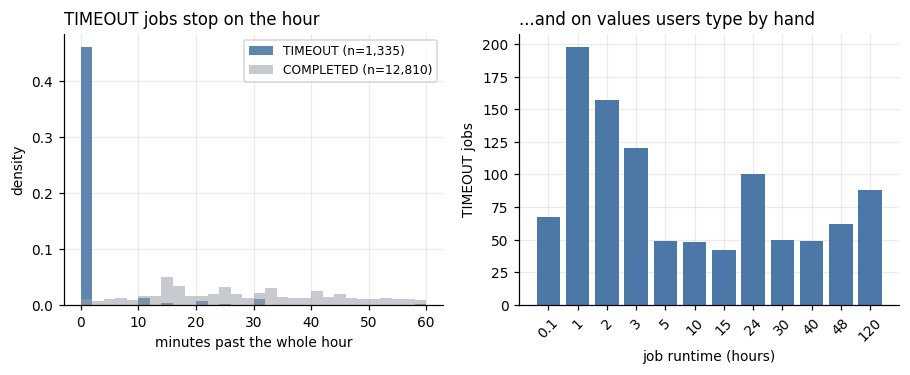

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(9.8, 3.2))
ax = axes[0]
for s, alpha in (("TIMEOUT", 0.9), ("COMPLETED", 0.55)):
    h = long_enough.loc[long_enough.state == s, "slurm_h"]
    off = ((h * 3600) % 3600) / 60
    ax.hist(off, bins=np.arange(0, 61, 2), density=True, alpha=alpha,
            color=COLOR[s], label=f"{s} (n={len(h):,})")
ax.set_xlabel("minutes past the whole hour"); ax.set_ylabel("density")
ax.legend(fontsize=8); ax.set_title("TIMEOUT jobs stop on the hour", loc="left")

ax = axes[1]
vc = tmo.slurm_h.round(1).value_counts().head(12).sort_index()
ax.bar(range(len(vc)), vc.values, color=COLOR["TIMEOUT"])
ax.set_xticks(range(len(vc)), [f"{v:g}" for v in vc.index], rotation=45)
ax.set_xlabel("job runtime (hours)"); ax.set_ylabel("TIMEOUT jobs")
ax.set_title("...and on values users type by hand", loc="left")
save(fig, "08_timeout_walltime.png"); plt.show()

The result is unambiguous: TIMEOUT runtimes cluster on whole hours far more than
COMPLETED runtimes do, and the most common values are exactly the ones a person
types into a submission script -- 1, 2, 3, 24, 48, 120 hours.

So TIMEOUT is overwhelmingly **a user under-estimating the walltime they need**,
not a node becoming unhealthy. It is still worth predicting -- a job about to be
killed at its limit is worth warning about -- but it is a different problem from
node-health prediction, and pooling it with FAILED, OOM and NODE_FAIL into a
single "failure" class mixes two unrelated phenomena. Notebook 03 keeps them
apart.

## 11. Column health

The table has 100 columns. Before choosing metrics for the windowing step in
notebook 02, we check which ones carry information at all: a column that is
constant, or almost constant, over the GPU population cannot help.

In [21]:
CANDIDATES = [
    "nvidia_gpu_temperature_celsius_mean", "nvidia_gpu_temperature_celsius_max",
    "nvidia_gpu_power_usage_milliwatts_mean", "nvidia_gpu_duty_cycle_mean",
    "nvidia_gpu_memory_used_bytes_sum", "nvidia_gpu_fanspeed_percent_mean",
    "node_memory_MemFree_bytes", "node_memory_Active_bytes", "node_memory_Dirty_bytes",
    "node_load1", "node_load15", "node_procs_running", "node_procs_blocked",
    "node_power_usage", "node_hwmon_temp_celsius_max", "node_thermal_zone_temp_max",
    "node_disk_written_bytes_total_sum", "node_network_receive_bytes_total_sum",
    "node_netstat_Tcp_InErrs", "node_netstat_Tcp_RetransSegs", "node_context_switches_total",
    "node_filesystem_avail_bytes_sum", "node_disk_io_now_sum", "node_forks_total",
]
# One part is enough to spot a dead column; use a part that is pure gpu_node=1.
probe = pq.read_table(sorted(RAW.glob("part-*.parquet"))[185],
                      columns=CANDIDATES + ["gpu_node", "state"])
probe = probe.filter((pc.field("gpu_node") == 1) & (pc.field("state") != "CANCELLED")).to_pandas()

health = pd.DataFrame({
    "null_%": probe[CANDIDATES].isna().mean() * 100,
    "distinct": probe[CANDIDATES].nunique(),
    "std": probe[CANDIDATES].std(),
}).sort_values("distinct")
health["verdict"] = np.where(health.distinct <= 1, "CONSTANT - unusable",
                     np.where(health.distinct < 20, "very coarse", "ok"))
print(f"probe rows: {len(probe):,}\n")
print(health.to_string(formatters={"null_%": "{:.2f}".format, "std": "{:.3g}".format}))

probe rows: 447,265

                                       null_%  distinct      std              verdict
node_disk_io_now_sum                     0.00         1        0  CONSTANT - unusable
node_netstat_Tcp_InErrs                  0.00         4    0.778          very coarse
node_hwmon_temp_celsius_max              0.00         9     1.08          very coarse
node_thermal_zone_temp_max               0.00        10     1.09          very coarse
node_procs_blocked                       0.00        23    0.594                   ok
node_power_usage                         0.00        47      227                   ok
node_procs_running                       0.00        50     5.78                   ok
nvidia_gpu_temperature_celsius_max       0.00        55     10.1                   ok
nvidia_gpu_fanspeed_percent_mean         0.00       171     9.68                   ok
nvidia_gpu_temperature_celsius_mean      0.00       178     9.69                   ok
nvidia_gpu_duty_cycle_mean       

No column is fully null, but several are very coarse -- `node_power_usage` and
the hwmon temperatures take only a few dozen distinct values across millions of
snapshots, so their within-window standard deviation will often be exactly zero.
That is worth knowing before reading the box plots in notebook 02.

The fourteen metrics carried into notebook 02 are taken only from the "ok" rows
and cover four subsystems: GPU, host memory, host load, and I/O. The constant and
very coarse columns are left out, which is why no thermal column other than the
GPU temperature appears there.

## 12. Summary

Numbers this notebook established, all recomputed from the raw table:

In [22]:
facts = {
    "snapshots in the full table": f"{n_snap_all:,}",
    "jobs in the full table": f"{n_jobs_all:,}",
    "GPU jobs": f"{len(gpu):,}",
    "GPU jobs after dropping CANCELLED": f"{len(jobs):,}",
    "GPU snapshots analysed": f"{len(snap):,}",
    "nodes": f"{jobs.node.nunique()}",
    "monitored period": f"{T0:%Y-%m-%d} to {T1:%Y-%m-%d} ({(T1-T0).days} days)",
    "job failure rate": f"{jobs.is_failure.mean():.1%}",
    "median FAILED runtime": f"{jobs.loc[jobs.state=='FAILED','slurm_h'].median()*60:.1f} min",
    "median TIMEOUT runtime": f"{jobs.loc[jobs.state=='TIMEOUT','slurm_h'].median():.1f} h",
    "failing jobs shorter than one window": f"{(jobs[jobs.is_failure].n_snap < WINDOW).mean():.1%}",
    "telemetry cadence": f"{np.median(dt):.0f} s",
    "intervals longer than the gap tolerance": f"{(dt > GAP_TOL_S).mean():.5%}",
    "snapshots shared with a co-tenant job": f"{dupe.mean():.1%}",
    "positives contradicted by a co-tenant": f"{floor/n_pos:.1%}",
    "TIMEOUT runtimes on a round hour": f"{round_hour_share(long_enough.loc[long_enough.state=='TIMEOUT','slurm_h']):.1%}",
    "COMPLETED runtimes on a round hour": f"{round_hour_share(long_enough.loc[long_enough.state=='COMPLETED','slurm_h']):.1%}",
    "train / test split time": f"{SPLIT_TIME}",
}
for k, v in facts.items():
    print(f"  {k:<45} {v}")
json.dump(facts, open(DATA / "facts_01.json", "w"), indent=2)

  snapshots in the full table                   93,950,875
  jobs in the full table                        293,891
  GPU jobs                                      27,287
  GPU jobs after dropping CANCELLED             23,618
  GPU snapshots analysed                        11,144,842
  nodes                                         51
  monitored period                              2022-08-25 to 2022-11-01 (68 days)
  job failure rate                              26.7%
  median FAILED runtime                         1.0 min
  median TIMEOUT runtime                        5.0 h
  failing jobs shorter than one window          66.8%
  telemetry cadence                             30 s
  intervals longer than the gap tolerance       0.00549%
  snapshots shared with a co-tenant job         78.4%
  positives contradicted by a co-tenant         51.7%
  TIMEOUT runtimes on a round hour              92.6%
  COMPLETED runtimes on a round hour            1.9%
  train / test split time              

### What this means for the pipeline

1. **The split must be temporal.** The weekly failure rate swings between 15 %
   and 39 %; a shuffled split would test on weeks the model has already seen.

2. **Coverage, not accuracy, is the binding constraint.** Most failing jobs are
   over before a 20-minute window can be formed. That ceiling is set here, in
   the data, before any model exists.

3. **The label is partly underdetermined.** 78 % of snapshots are shared between
   concurrent jobs on the same node, and about half of all positive snapshots sit
   on a row that also serves a job which does not fail. Node-level features
   cannot separate those, so there is a recall ceiling near 48 % that no
   algorithm can pass. The exclusive queues are where the problem is well posed.

4. **TIMEOUT is a different phenomenon.** It is a walltime under-estimate, not a
   sick node, and it dominates the positive class. It should be modelled and
   reported separately.

Notebook 02 builds the windows and the labels, and looks at what the aggregated
features actually contain.